In [1]:
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import hamming
from matplotlib import pyplot as plt
import numpy as np
import copy
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
df = pd.read_csv("1000Mvla01.csv")
df.shape

(1000, 51)

In [3]:
df.columns = ['cout'] + [i for i in range(1, 51)]
df.index = ["v" + str(i) for i in range(1000)]


In [4]:
df.head()

,cout,1,2,3,4,5,6,7,8,9,...,41,42,43,44,45,46,47,48,49,50
v0,1117,1,4,7,2,4,7,3,9,1,...,3,10,4,10,6,3,5,3,5,10
v1,1228,5,4,2,6,6,5,2,6,3,...,5,9,8,8,3,3,3,2,1,1
v2,887,10,3,7,2,8,1,2,8,6,...,4,9,10,5,7,6,3,3,9,5
v3,1197,6,7,5,1,3,9,5,7,8,...,2,5,2,2,6,6,4,2,1,6
v4,1190,3,10,6,10,5,5,3,9,9,...,3,9,3,9,2,8,8,2,2,2


In [5]:
df1 = df.T
df1

,v0,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v990,v991,v992,v993,v994,v995,v996,v997,v998,v999
cout,1117,1228,887,1197,1190,1077,1128,975,1287,1281,...,1339,1201,1373,1256,1054,1249,994,1061,1091,1261
1,1,5,10,6,3,7,4,4,3,8,...,7,2,9,4,8,3,9,3,8,10
2,4,4,3,7,10,9,7,1,10,8,...,10,4,1,6,8,4,8,6,10,2
3,7,2,7,5,6,2,10,1,6,2,...,5,9,6,2,6,1,4,8,1,7
4,2,6,2,1,10,1,1,5,6,9,...,9,6,4,4,2,6,4,2,7,4
5,4,6,8,3,5,3,4,10,1,2,...,2,5,9,3,3,9,10,1,10,6
6,7,5,1,9,5,7,5,7,3,8,...,4,8,1,5,3,2,5,4,2,6
7,3,2,2,5,3,9,7,1,1,5,...,5,1,7,1,6,3,9,8,9,2
8,9,6,8,7,9,3,4,6,4,6,...,3,7,3,5,7,5,8,7,1,6
9,1,3,6,8,9,9,5,6,4,6,...,4,2,7,3,8,9,6,1,2,3


In [6]:
df['cout'].value_counts()

1105    8
1118    7
1192    7
1066    6
1070    6
       ..
1405    1
903     1
1300    1
915     1
1336    1
Name: cout, Length: 463, dtype: int64

In [28]:
l = df1.columns
Hamming_distance = []
for x in l :
    L = []
    for y in l :
        L.append(hamming(df1[x].values, df1[y].values) * 50)
    Hamming_distance.append(L)


In [29]:
distance_df = pd.DataFrame(Hamming_distance)
distance_df.to_csv("distances entres vecteurs")

In [30]:
distance_df.head()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0.000000,45.098039,44.117647,47.058824,47.058824,43.137255,47.058824,44.117647,43.137255,43.137255,...,47.058824,45.098039,48.039216,47.058824,49.019608,46.078431,46.078431,47.058824,48.039216,46.078431
1,45.098039,0.000000,41.176471,42.156863,47.058824,44.117647,45.098039,44.117647,45.098039,44.117647,...,48.039216,43.137255,45.098039,43.137255,46.078431,44.117647,48.039216,46.078431,45.098039,42.156863
2,44.117647,41.176471,0.000000,46.078431,44.117647,44.117647,42.156863,44.117647,50.000000,42.156863,...,49.019608,47.058824,45.098039,44.117647,49.019608,45.098039,45.098039,42.156863,45.098039,44.117647
3,47.058824,42.156863,46.078431,0.000000,48.039216,47.058824,43.137255,48.039216,48.039216,46.078431,...,44.117647,47.058824,49.019608,48.039216,42.156863,48.039216,45.098039,45.098039,44.117647,44.117647
4,47.058824,47.058824,44.117647,48.039216,0.000000,46.078431,37.254902,44.117647,45.098039,45.098039,...,43.137255,44.117647,46.078431,45.098039,44.117647,43.137255,43.137255,47.058824,44.117647,49.019608


In [31]:
max_i = L.index(max(L))
distances_sol_op = Hamming_distance[max_i]
distances_sol_op

[41.17647058823529,
 42.15686274509804,
 46.07843137254902,
 44.11764705882353,
 45.09803921568628,
 43.13725490196079,
 42.15686274509804,
 46.07843137254902,
 46.07843137254902,
 43.13725490196079,
 43.13725490196079,
 44.11764705882353,
 47.05882352941176,
 43.13725490196079,
 45.09803921568628,
 46.07843137254902,
 49.01960784313725,
 48.03921568627451,
 48.03921568627451,
 47.05882352941176,
 48.03921568627451,
 43.13725490196079,
 46.07843137254902,
 50.0,
 48.03921568627451,
 46.07843137254902,
 45.09803921568628,
 47.05882352941176,
 45.09803921568628,
 45.09803921568628,
 45.09803921568628,
 45.09803921568628,
 45.09803921568628,
 41.17647058823529,
 46.07843137254902,
 43.13725490196079,
 48.03921568627451,
 43.13725490196079,
 48.03921568627451,
 45.09803921568628,
 48.03921568627451,
 45.09803921568628,
 42.15686274509804,
 48.03921568627451,
 46.07843137254902,
 42.15686274509804,
 45.09803921568628,
 46.07843137254902,
 47.05882352941176,
 44.11764705882353,
 49.019607843

In [32]:
def get_neighbors(k) :
    L =  copy.deepcopy(distances_sol_op)
    M = []
    min_v = min(L)
    for i in range(k) :
        max_v = max(L)
        indice = L.index(max_v)
        M.append(indice)
        L[indice] = min_v
    return M

In [33]:
neighbors = get_neighbors(5)
neighbors

[23, 67, 509, 571, 999]

In [34]:
def split_list(string) :
    length = len(string)
    splited_list = []
    for i in range(length) :
        for j in range(i+1, length) :
            if len(string[i:j+1]) > 1 :
                splited_list.append(string[i:j+1])
    return splited_list

In [35]:
def get_similar_subsequences(arr1,arr2, length) :
    common_sequences = []
    i = 0
    while i < length :
        seq = []
        while i < length and arr1[i] == arr2[i] :
            seq.append(arr1[i])
            i = i + 1
        if len(seq) > 1 :
            L = split_list(seq)
            for x in L :
                common_sequences.append(x)
        i = i + 1
    return common_sequences

In [36]:
get_similar_subsequences(df1['v9'].values, df1['v23'].values, 50)

[[6, 3], [7, 10]]

In [37]:
def get_vectors_similar_subs() :
    similar_subs_matrix = []
    length = len(df1['v0'].values)
    for i in range(5) :
        vi = 'v' + str(neighbors[i])
        for j in range(i + 1, 5) :
            vj = 'v' + str(neighbors[j])
            similar_subs_matrix.append(get_similar_subsequences(df1[vi].values, df1[vj].values, length))
    return similar_subs_matrix

In [38]:
L = get_vectors_similar_subs()

In [39]:
L

[[[10, 4], [9, 9]],
 [[5, 4]],
 [[5, 4], [9, 10]],
 [],
 [],
 [],
 [],
 [[3, 5], [3, 5, 4], [5, 4], [1, 4]],
 [],
 [[8, 8]]]

In [40]:
sub_sequences = []
for x in L :
    for y in x :
        if y not in sub_sequences :
            sub_sequences.append(y)

sub_sequences

[[10, 4], [9, 9], [5, 4], [9, 10], [3, 5], [3, 5, 4], [1, 4], [8, 8]]

In [41]:
def count_occurence(x,T) :
    cmpt = 0;
    for y in T :
        for z in y :
            if z == x :
                cmpt = cmpt + 1
    return cmpt

In [42]:
frequences = {}
for x in sub_sequences :
    frequences[str(x)] = count_occurence(x,L)

In [43]:
frequences 

{'[10, 4]': 1,
 '[9, 9]': 1,
 '[5, 4]': 3,
 '[9, 10]': 1,
 '[3, 5]': 1,
 '[3, 5, 4]': 1,
 '[1, 4]': 1,
 '[8, 8]': 1}

In [44]:
x = list(frequences.keys())
y = list(frequences.values()) 
y = [(x / 50) * 100 for x in y]
y

[2.0, 2.0, 6.0, 2.0, 2.0, 2.0, 2.0, 2.0]

<AxesSubplot:>

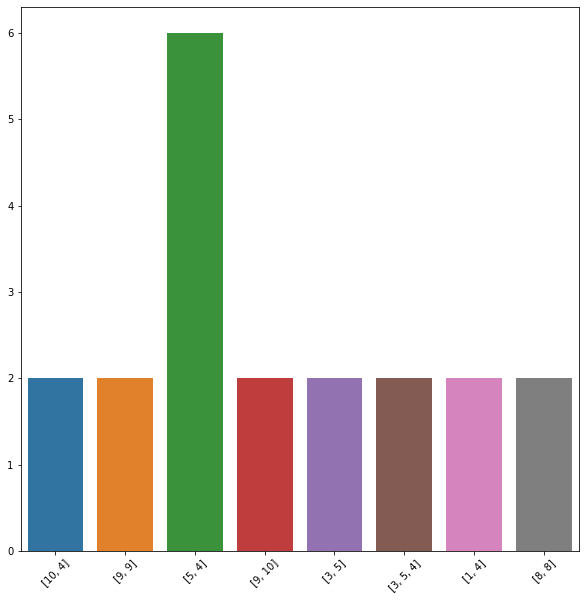

In [ ]:
fig, ax = plt.subplots(figsize = (10,10))
plt.xticks(rotation=45)
sns.barplot(x,y, ax = ax)